In [12]:
import umap
import matplotlib.pyplot as plt
import pickle
from collections import Counter
import numpy as np
import json
from matplotlib.lines import Line2D
from matplotlib.colors import BoundaryNorm
from sklearn.manifold import MDS
from sklearn.manifold import SpectralEmbedding

In [21]:
with open("../../Data/disease_to_snomed_id.json", "r") as f:
    d = json.load(f)

DISEASE_list = list(d.keys())
DISEASE_list.append("NONE")
print(DISEASE_list)

['BIPOLAR', 'SCHIZOPHRENIA', 'LEUKEMIA', 'PARKINSON', 'DIABETES', 'BREASTCANCER', 'NONE']


In [14]:
num_neighbors = 400

In [15]:
reducer = umap.UMAP(metric='precomputed', n_neighbors=num_neighbors, random_state=42)
mds = MDS(
    n_components=2,
    dissimilarity="precomputed",
    random_state=42
)
spec = SpectralEmbedding(
    n_components=2,
    affinity="precomputed"
)

In [16]:
def collapse_labels_top_k(labels, k=15, other_label=-1):
    """
    Keep only the top-k most frequent labels.
    All other labels are replaced by `other_label`.

    labels: 1D array-like of ints
    k: number of most frequent labels to keep
    other_label: label assigned to all collapsed groups

    Returns:
        labels_new -- collapsed label array
        keep_map   -- mapping of kept labels to themselves
        top_labels -- list of top-k labels
    """
    labels = np.asarray(labels)

    # Count frequencies
    freq = Counter(labels)

    # Top-k labels by frequency
    top_labels = [lbl for lbl, _ in freq.most_common(k)]

    # Build new labels array
    labels_new = np.array([
        lbl if lbl in top_labels else other_label
        for lbl in labels
    ])

    return labels_new, top_labels


In [17]:
def umap_embedding(DISEASE, option):
    RESULT_FOLDER = f"../output/{DISEASE}/leiden_results"
    with open(f"{RESULT_FOLDER}/diffusion_dist_agg_sym.pkl", "rb") as f:
        diffusion_dist_agg_sym = pickle.load(f)
    with open(f"{RESULT_FOLDER}/labels.pkl", "rb") as f:
        labels = pickle.load(f)
    with open(f"{RESULT_FOLDER}/result_communities_selected.pkl", "rb") as f:
        communities_selected = pickle.load(f)
    top_m = len(communities_selected)
    labels_collapsed, top_labels = collapse_labels_top_k(labels, k=top_m, other_label=-1)

    print("Top m labels:", top_labels)
    print("Unique labels after collapsing:", np.unique(labels_collapsed))
    
    if (option == "UMAP"):
        embedding = reducer.fit_transform(diffusion_dist_agg_sym)
    elif (option == "MDS"):
        embedding = mds.fit_transform(diffusion_dist_agg_sym.toarray())
    elif (option == "SPEC"):
        embedding = spec.fit_transform(diffusion_dist_agg_sym)
    return embedding, labels_collapsed

Top m labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Unique labels after collapsing: [-1  0  1  2  3  4  5  6  7  8  9]


c:\Users\celem\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")


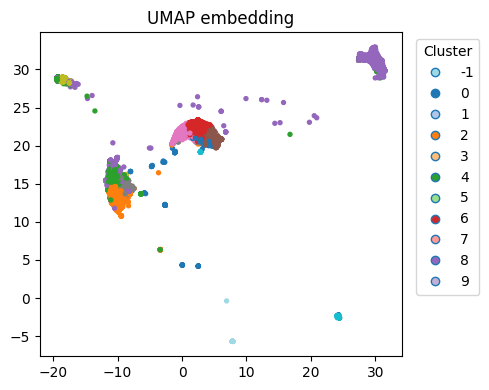

Top m labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Unique labels after collapsing: [-1  0  1  2  3  4  5  6  7  8  9 10]


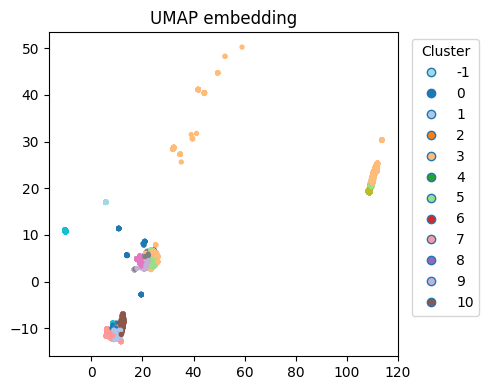

FileNotFoundError: [Errno 2] No such file or directory: '../output/LEUKEMIA/leiden_results/labels.pkl'

In [22]:
for disease in DISEASE_list:
    embedding, labels_collapsed = umap_embedding(disease,"UMAP")

    plt.figure(figsize=(5,4))

    # Single scatter call
    plt.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=labels_collapsed,
        cmap="tab20",
        s=8
    )

    plt.title("UMAP embedding")

    # Proper categorical legend
    unique_labels = np.unique(labels_collapsed)
    cmap = plt.get_cmap("tab20")

    handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="",
            markersize=6,
            markerfacecolor=cmap(lab % cmap.N),
            label=str(lab)
        )
        for lab in unique_labels
    ]

    plt.legend(
        handles=handles,
        title="Cluster",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

